In [1]:
import torch
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RANDOMSEED=42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
n_samples = 1000

X, y = sklearn.datasets.make_circles(n_samples, noise=.03, random_state=RANDOMSEED)
X.shape, y.shape, X[:3], y[:3]

((1000, 2),
 (1000,),
 array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203]]),
 array([1, 1, 1]))

In [3]:
circles = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "label": y
})
circles.head(5)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [4]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

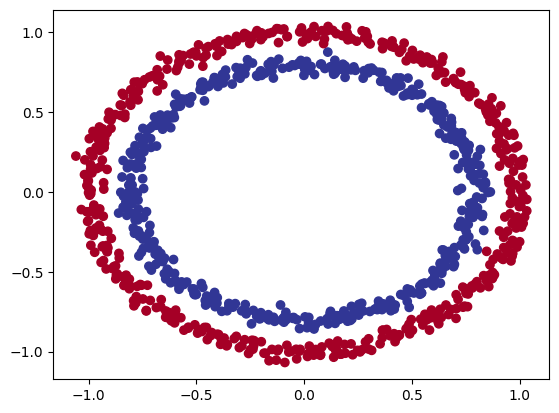

In [5]:
plt.scatter(x=circles.X1, y=circles.X2, c=y, cmap=plt.cm.RdYlBu)

In [6]:
X = torch.from_numpy(X).type(torch.float).to(device)
y = torch.from_numpy(y).type(torch.float).to(device)
X[:3], y[:3]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733]], device='cuda:0'),
 tensor([1., 1., 1.], device='cuda:0'))

In [7]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=.2, random_state=RANDOMSEED)

In [8]:
class CircleModelV0(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=2, out_features=5)
        self.layer_2 = torch.nn.Linear(in_features=5, out_features=1)
    def forward(self, x):
        return self.layer_2(self.layer_1(x))

In [9]:
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [10]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=.1)

In [11]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
torch.manual_seed(RANDOMSEED)

epochs = 100

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc: .2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71721, Accuracy:  50.00% | Test loss:  0.71068, Test acc: 50.00%
Epoch: 10 | Loss: 0.70139, Accuracy:  50.00% | Test loss:  0.69733, Test acc: 50.00%
Epoch: 20 | Loss: 0.69633, Accuracy:  50.00% | Test loss:  0.69340, Test acc: 50.00%
Epoch: 30 | Loss: 0.69458, Accuracy:  42.75% | Test loss:  0.69230, Test acc: 43.50%
Epoch: 40 | Loss: 0.69393, Accuracy:  46.00% | Test loss:  0.69208, Test acc: 50.50%
Epoch: 50 | Loss: 0.69365, Accuracy:  47.12% | Test loss:  0.69213, Test acc: 53.00%
Epoch: 60 | Loss: 0.69351, Accuracy:  48.50% | Test loss:  0.69225, Test acc: 53.00%
Epoch: 70 | Loss: 0.69343, Accuracy:  49.12% | Test loss:  0.69239, Test acc: 53.00%
Epoch: 80 | Loss: 0.69337, Accuracy:  49.38% | Test loss:  0.69252, Test acc: 52.50%
Epoch: 90 | Loss: 0.69332, Accuracy:  49.50% | Test loss:  0.69265, Test acc: 53.50%


In [13]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


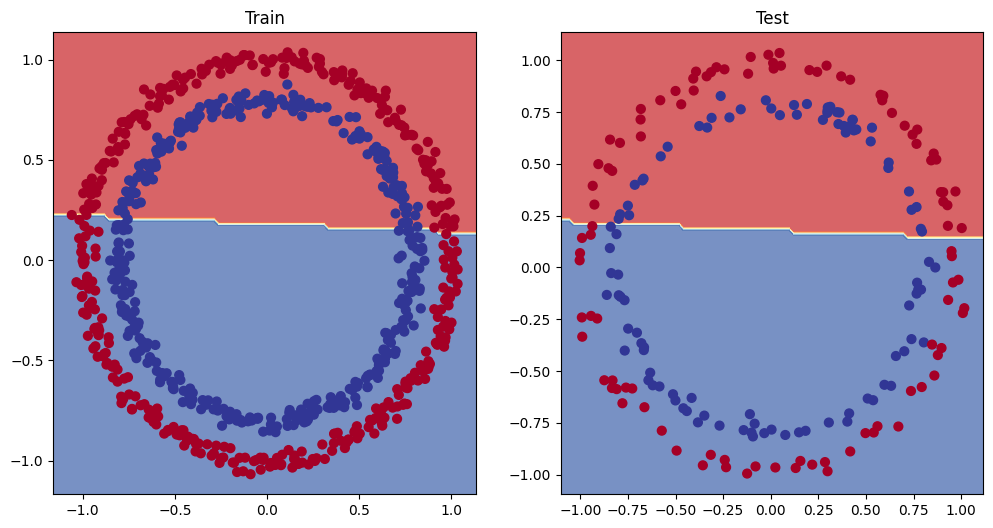

In [14]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [15]:
class CircleModelV1(torch.nn.Module):
    def __init__(self):
        torch.nn.Module.__init__(self)
        self.layer_1 = torch.nn.Linear(in_features=2, out_features=10)
        self.layer_2 = torch.nn.Linear(in_features=10, out_features=10)
        self.layer_3 = torch.nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [16]:
model_1 = CircleModelV1().to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=.1)

In [17]:
torch.manual_seed(RANDOMSEED)

epochs = 1000

for epoch in range(epochs):
    model_1.train()

    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model_1.eval()
        with torch.inference_mode():
            test_y_logits = model_1(X_test).squeeze()
            test_y_pred = torch.round(torch.sigmoid(test_y_logits))
    
            test_acc = accuracy_fn(y_true=y_test, y_pred=test_y_pred)
            test_loss = loss_fn(test_y_logits, y_test)
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc: .2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")
            

Epoch: 0 | Loss: 0.69396, Accuracy:  50.88% | Test loss:  0.69261, Test acc: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy:  50.38% | Test loss:  0.69379, Test acc: 48.00%
Epoch: 200 | Loss: 0.69299, Accuracy:  51.12% | Test loss:  0.69437, Test acc: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy:  51.62% | Test loss:  0.69458, Test acc: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy:  51.12% | Test loss:  0.69465, Test acc: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy:  51.00% | Test loss:  0.69467, Test acc: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy:  51.00% | Test loss:  0.69468, Test acc: 46.00%
Epoch: 700 | Loss: 0.69298, Accuracy:  51.00% | Test loss:  0.69468, Test acc: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy:  51.00% | Test loss:  0.69468, Test acc: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy:  51.00% | Test loss:  0.69468, Test acc: 46.00%


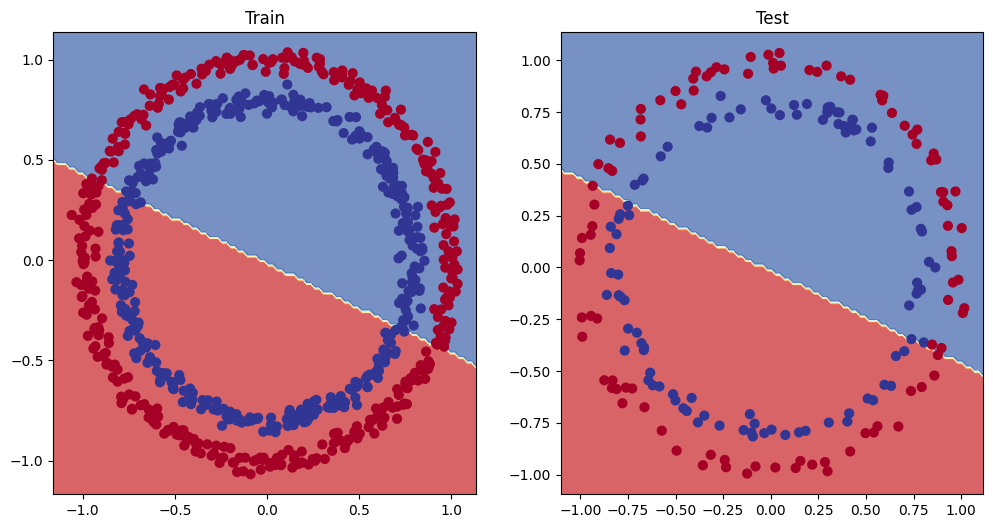

In [18]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [19]:
class CircleModelV2(torch.nn.Module):
    def __init__(self):
        torch.nn.Module.__init__(self)
        self.layer_1 = torch.nn.Linear(in_features=2, out_features=10)
        self.layer_2 = torch.nn.Linear(in_features=10, out_features=10)
        self.layer_3 = torch.nn.Linear(in_features=10, out_features=1)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [20]:
model_2 = CircleModelV2().to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=.1)

In [21]:
torch.manual_seed(RANDOMSEED)

epochs = 1000

for epoch in range(epochs):
    model_2.train()

    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model_1.eval()
        with torch.inference_mode():
            test_y_logits = model_2(X_test).squeeze()
            test_y_pred = torch.round(torch.sigmoid(test_y_logits))
    
            test_acc = accuracy_fn(y_true=y_test, y_pred=test_y_pred)
            test_loss = loss_fn(test_y_logits, y_test)
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc: .2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")
            

Epoch: 0 | Loss: 0.69295, Accuracy:  50.00% | Test loss:  0.69319, Test acc: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy:  52.88% | Test loss:  0.69102, Test acc: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy:  53.37% | Test loss:  0.68940, Test acc: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy:  53.00% | Test loss:  0.68723, Test acc: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy:  52.75% | Test loss:  0.68411, Test acc: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy:  52.75% | Test loss:  0.67941, Test acc: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy:  54.50% | Test loss:  0.67285, Test acc: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy:  58.38% | Test loss:  0.66322, Test acc: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy:  64.00% | Test loss:  0.64757, Test acc: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy:  74.00% | Test loss:  0.62145, Test acc: 79.00%


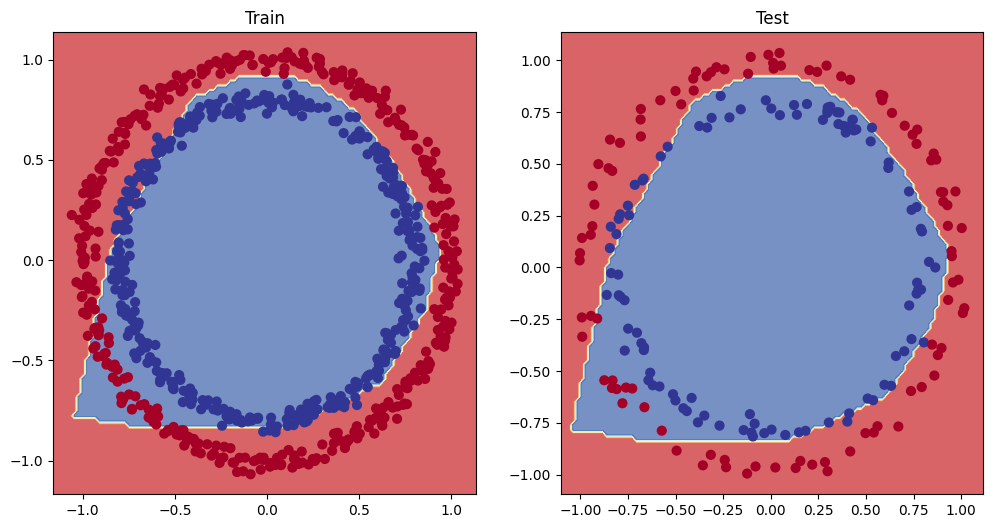

In [22]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

In [23]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = sklearn.datasets.make_blobs(n_samples=n_samples, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)
X_blob_train, X_blob_test, y_blob_train, y_blob_test = sklearn.model_selection.train_test_split(X_blob, y_blob, test_size=.2, random_state=RANDOM_SEED)
X_blob_train = torch.from_numpy(X_blob_train).type(torch.float).to(device)
X_blob_test = torch.from_numpy(X_blob_test).type(torch.float).to(device)
y_blob_train = torch.from_numpy(y_blob_train).type(torch.LongTensor).to(device)
y_blob_test = torch.from_numpy(y_blob_test).type(torch.LongTensor).to(device)
X_blob_train[:3], y_blob_train[:3]

(tensor([[ 5.0405,  3.3076],
         [-2.6249,  9.5260],
         [-8.5240, -9.0402]], device='cuda:0'),
 tensor([1, 0, 2], device='cuda:0'))

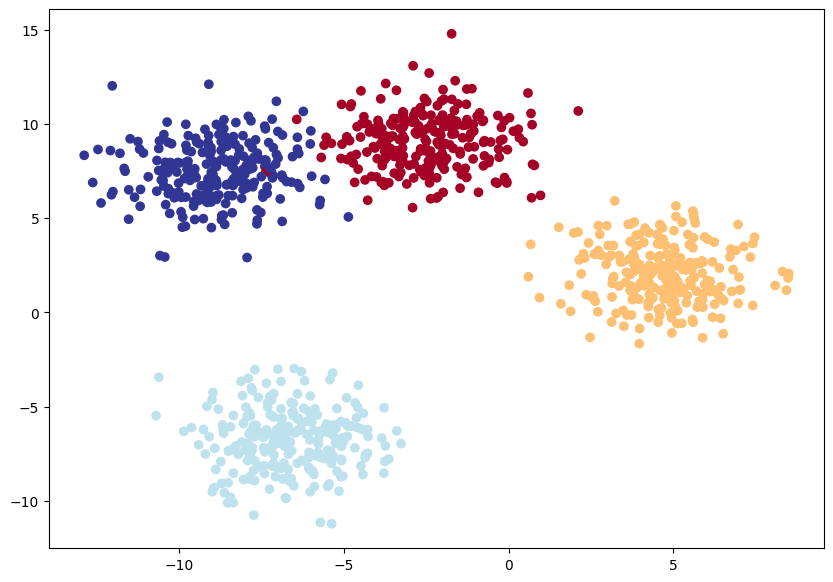

In [24]:
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

In [25]:
class BlobModel(torch.nn.Module):
    def __init__(self, input_features, output_features, hidden_unit=8):
        torch.nn.Module.__init__(self)
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(in_features=input_features, out_features=hidden_unit),
            # torch.nn.ReLU(),
            torch.nn.Linear(in_features=hidden_unit, out_features=hidden_unit),
            # torch.nn.ReLU(),
            torch.nn.Linear(in_features=hidden_unit, out_features=output_features)
        )
    def forward(self, x):
        return self.layer(x)

In [26]:
model_3 = BlobModel(NUM_FEATURES, NUM_CLASSES, hidden_unit=8).to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=.01)

In [27]:
torch.manual_seed(RANDOM_SEED)
epochs = 100

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model_3.eval()
        with torch.inference_mode():
            test_y_logits = model_3(X_blob_test)
            test_y_pred = torch.softmax(test_y_logits, dim=1).argmax(dim=1)
            test_loss = loss_fn(test_y_logits, y_blob_test)
            test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_y_pred)
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.04324, Acc: 65.50% | Test Loss: 0.96335, Test Acc: 71.00%
Epoch: 10 | Loss: 0.63688, Acc: 79.50% | Test Loss: 0.61222, Test Acc: 88.00%
Epoch: 20 | Loss: 0.46945, Acc: 97.75% | Test Loss: 0.45865, Test Acc: 98.00%
Epoch: 30 | Loss: 0.37339, Acc: 98.50% | Test Loss: 0.36771, Test Acc: 99.00%
Epoch: 40 | Loss: 0.31009, Acc: 98.62% | Test Loss: 0.30659, Test Acc: 99.00%
Epoch: 50 | Loss: 0.26486, Acc: 98.88% | Test Loss: 0.26227, Test Acc: 99.00%
Epoch: 60 | Loss: 0.23082, Acc: 98.88% | Test Loss: 0.22853, Test Acc: 99.50%
Epoch: 70 | Loss: 0.20429, Acc: 99.12% | Test Loss: 0.20197, Test Acc: 99.50%
Epoch: 80 | Loss: 0.18307, Acc: 99.12% | Test Loss: 0.18057, Test Acc: 99.00%
Epoch: 90 | Loss: 0.16578, Acc: 99.12% | Test Loss: 0.16301, Test Acc: 99.00%


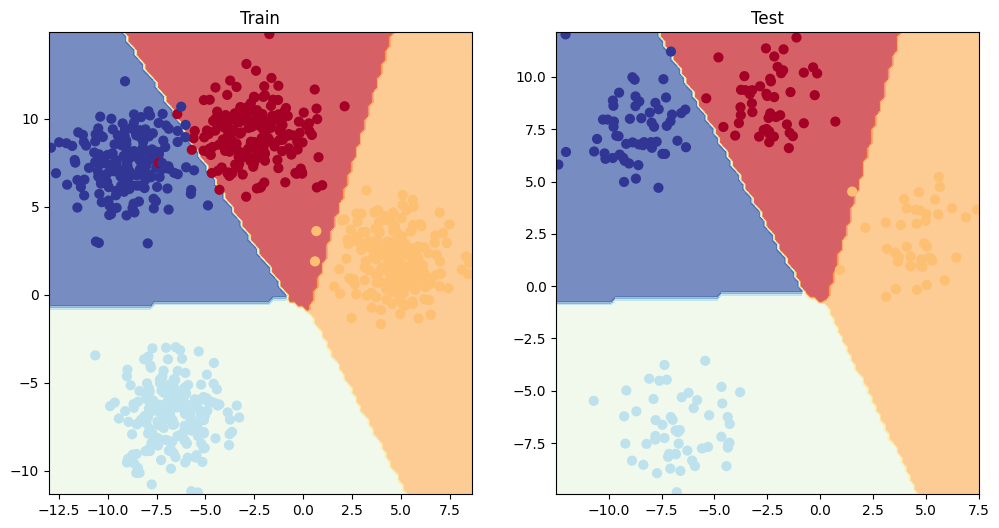

In [28]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_blob_test, y_blob_test)

In [29]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(test_y_pred, y_blob_test)

/opt/data/uv_envs/p310/.venv/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


tensor(0.9900, device='cuda:0')

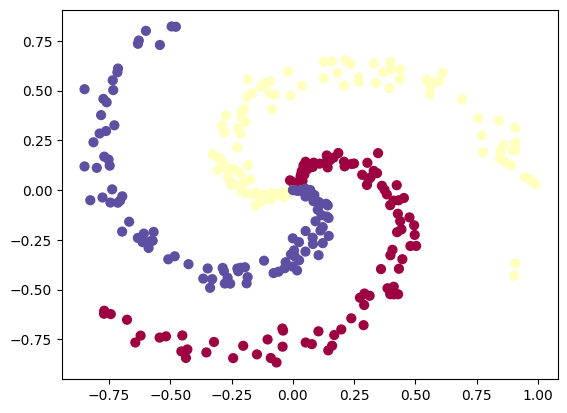

In [30]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()